In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
import cartopy.crs as ccrs

In [12]:
# gs_path = "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr/"

gs_path = "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-64x32_equiangular_conservative.zarr/"

dataset = xr.open_zarr(gs_path)

dataset

<xarray.Dataset>
Dimensions:                                           (time: 93544,
                                                       longitude: 64,
                                                       latitude: 32, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 -87....
  * level                                             (level) int64 50 ... 1000
  * longitude                                         (longitude) float64 0.0...
  * time                                              (time) datetime64[ns] 1...
Data variables: (12/62)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    above_ground                                      (time, level, longitude, latitude) float32 dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    ...                                                ...
    volumetric_soil_water_layer_1                     (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_2                     (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_3                     (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    volumetric_soil_water_layer_4                     (time, longitude, latitude) float32 dask.array<chunksize=(100, 64, 32), meta=np.ndarray>
    vorticity                                         (time, level, longitude, latitude) float32 dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 dask.array<chunksize=(100, 13, 64, 32), meta=np.ndarray>

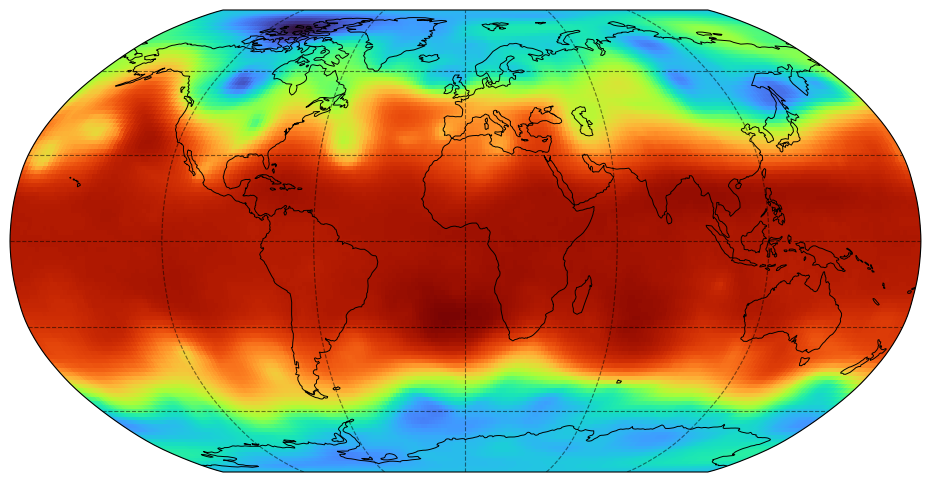

In [19]:
sst_plot = dataset["geopotential"].isel(time=20).sel(level=500)

subplot_kws=dict(projection=ccrs.Robinson(),
                 facecolor='grey')

plt.figure(figsize=[12,6])
p = sst_plot.plot(x='longitude', y='latitude',
                  subplot_kws=subplot_kws,
                  cmap='turbo',
                  transform=ccrs.PlateCarree(),
                  add_labels=False,
                  add_colorbar=False)

# add separate colorbar
# cb = plt.colorbar(p, shrink=0.6)
# cb.ax.tick_params(labelsize=18)

p.axes.gridlines(color='black', alpha=0.5, linestyle='--')
p.axes.coastlines(color='black', linewidth=0.7)

plt.savefig("era5-z500-transparent_2.png", dpi=300, transparent=True)

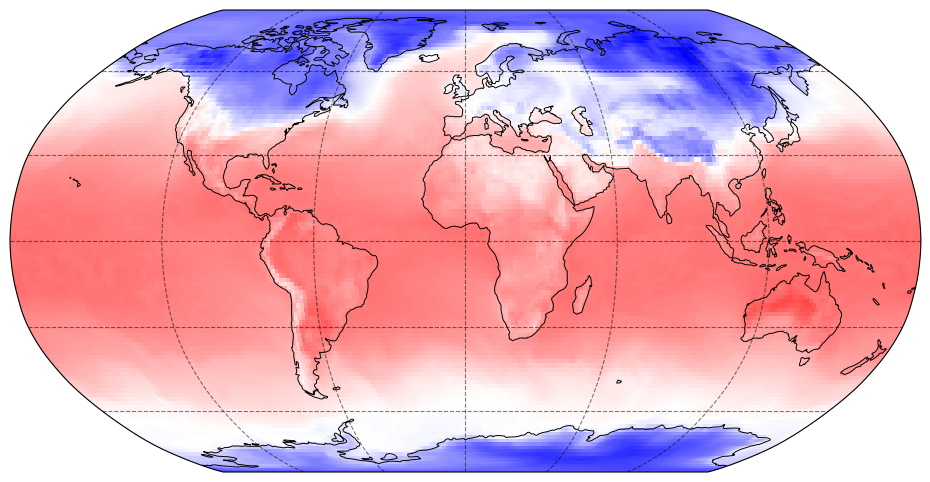

In [3]:
sst_plot = dataset["2m_temperature"].isel(time=600) - 273.15

subplot_kws=dict(projection=ccrs.Robinson(),
                 facecolor='grey')

plt.figure(figsize=[12,6])
p = sst_plot.plot(x='longitude', y='latitude',
                  subplot_kws=subplot_kws,
                  cmap='bwr',
                  transform=ccrs.PlateCarree(),
                  add_labels=False,
                  add_colorbar=False)

# add separate colorbar
# cb = plt.colorbar(p, shrink=0.6)
# cb.ax.tick_params(labelsize=18)

p.axes.gridlines(color='black', alpha=0.5, linestyle='--')
p.axes.coastlines(color='black', linewidth=0.7)

plt.show()

# plt.savefig("era5-t2m-transparent_2.png", dpi=300, transparent=True)

(256, 512)


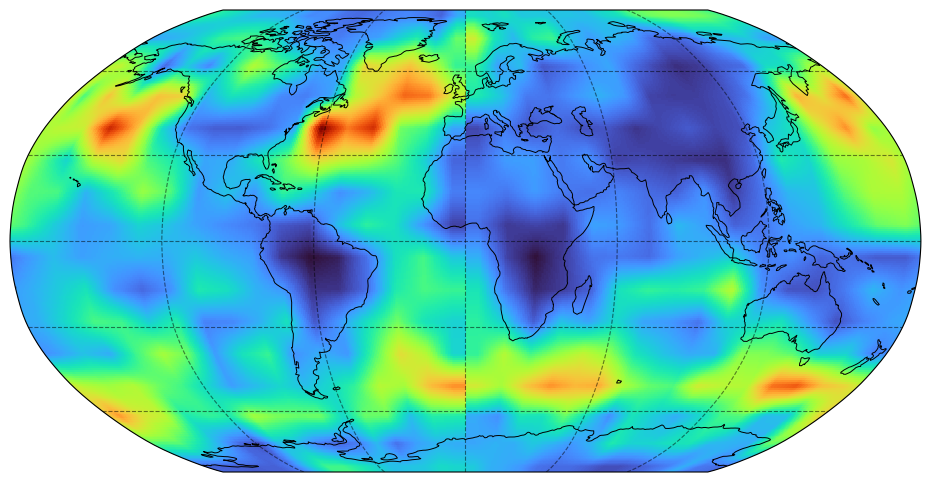

In [33]:
import torch

sst_plot = dataset["10m_wind_speed"].isel(time=0)

data = sst_plot.values

# upsampling with linear interpolation to get a smoother plot
data = torch.tensor(data).unsqueeze(0).unsqueeze(0) 

# downsample to 64x32
data = torch.nn.functional.interpolate(data, scale_factor=0.5, mode='bilinear')

data = torch.nn.functional.interpolate(data, scale_factor=16, mode='bilinear')
data = data.squeeze().squeeze().numpy()


# transpose data for plotting
data = data.T
print(data.shape)

new_lon = np.linspace(0, 360, 512)
new_lat = np.linspace(-90, 90, 256)

sst_plot = xr.DataArray(data, coords=[new_lat, new_lon], dims=['latitude', 'longitude'])


subplot_kws=dict(projection=ccrs.Robinson(),
                 facecolor='grey')

plt.figure(figsize=[12,6])
p = sst_plot.plot(x='longitude', y='latitude',
                  subplot_kws=subplot_kws,
                  cmap='turbo',
                  transform=ccrs.PlateCarree(),
                  add_labels=False,
                  add_colorbar=False)

# add separate colorbar
# cb = plt.colorbar(p, shrink=0.6)
# cb.ax.tick_params(labelsize=18)

p.axes.gridlines(color='black', alpha=0.5, linestyle='--')
p.axes.coastlines(color='black', linewidth=0.7)

# plt.show()

plt.savefig("era5-ws10-transparent_low_res.png", dpi=300, transparent=True)

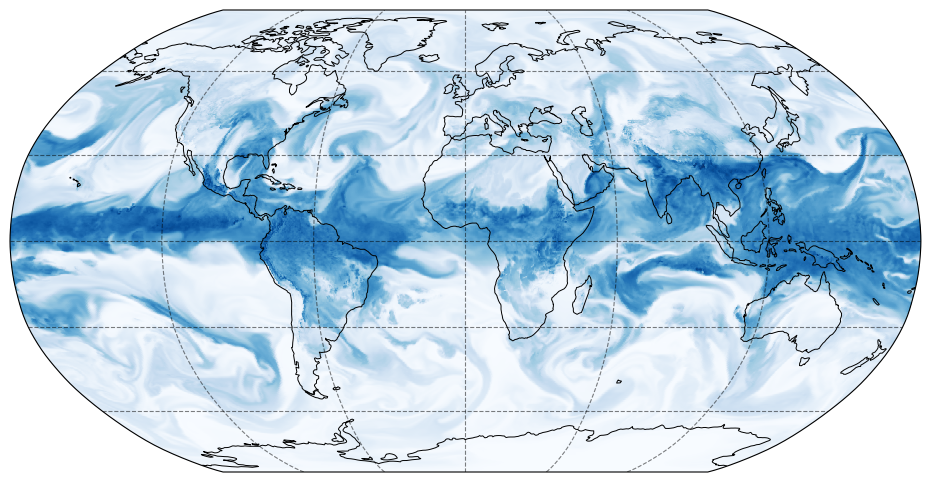

In [21]:
sst_plot = dataset["specific_humidity"].isel(time=600).sel(level=700)

subplot_kws=dict(projection=ccrs.Robinson(),
                 facecolor='grey')

plt.figure(figsize=[12,6])
p = sst_plot.plot(x='longitude', y='latitude',
                  subplot_kws=subplot_kws,
                  cmap='Blues',
                  transform=ccrs.PlateCarree(),
                  add_labels=False,
                  add_colorbar=False)

# add separate colorbar
# cb = plt.colorbar(p, shrink=0.6)
# cb.ax.tick_params(labelsize=18)

p.axes.gridlines(color='black', alpha=0.5, linestyle='--')
p.axes.coastlines(color='black', linewidth=0.7)

plt.savefig("era5-h700-transparent_2.png", dpi=300, transparent=True)

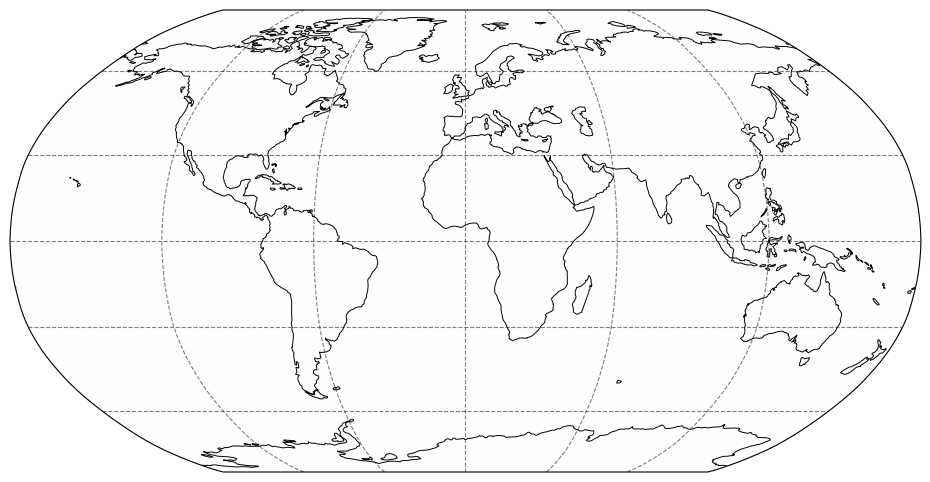

In [22]:
lat = np.linspace(-90, 90, 64)
lon = np.linspace(0, 360, 128)

data = np.zeros((len(lat), len(lon)))

ds = xr.DataArray(data, coords=[lat, lon], dims=["lat", "lon"])

#sst_plot = dataset["specific_humidity"].isel(time=300).sel(level=700)

subplot_kws=dict(projection=ccrs.Robinson(),
                 facecolor='grey')

plt.figure(figsize=[12,6])
p = ds.plot(x='lon', y='lat',
                  subplot_kws=subplot_kws,
                  cmap="bwr",
                  transform=ccrs.PlateCarree(),
                  add_labels=False,
                  add_colorbar=False)

# add separate colorbar
# cb = plt.colorbar(p, shrink=0.6)
# cb.ax.tick_params(labelsize=18)

p.axes.gridlines(color='black', alpha=0.5, linestyle='--')
p.axes.coastlines(color='black', linewidth=0.7)

#plt.savefig("era5-blank-map-transparent", dpi=300, transparent=True)